## EDA

BAS_2025: n=583,624  min=17.79  max=70.72  mean=29.41
BRC_2022: n=253,573  min=20.03  max=60.39  mean=30.09
BRC_2023: n=327,688  min=1.22  max=71.42  mean=24.72
DZM_2013: n=655,765  min=22.51  max=58.66  mean=32.94
DZM_2014: n=371,803  min=21.28  max=51.41  mean=31.27
DZM_2019: n=184,725  min=15.44  max=71.60  mean=37.53
DZM_2023: n=358,746  min=19.92  max=61.26  mean=28.94
HAUT_2025: n=825,902  min=12.96  max=61.33  mean=30.80
PDR_2013: n=283,927  min=13.51  max=47.88  mean=28.32
PDR_2014: n=252,186  min=11.54  max=58.99  mean=27.98
PDR_2023: n=1,060,414  min=9.06  max=67.18  mean=30.03


/tmp/ipykernel_3232303/1504571781.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(stats.values(), labels=stats.keys(), vert=True, patch_artist=True)


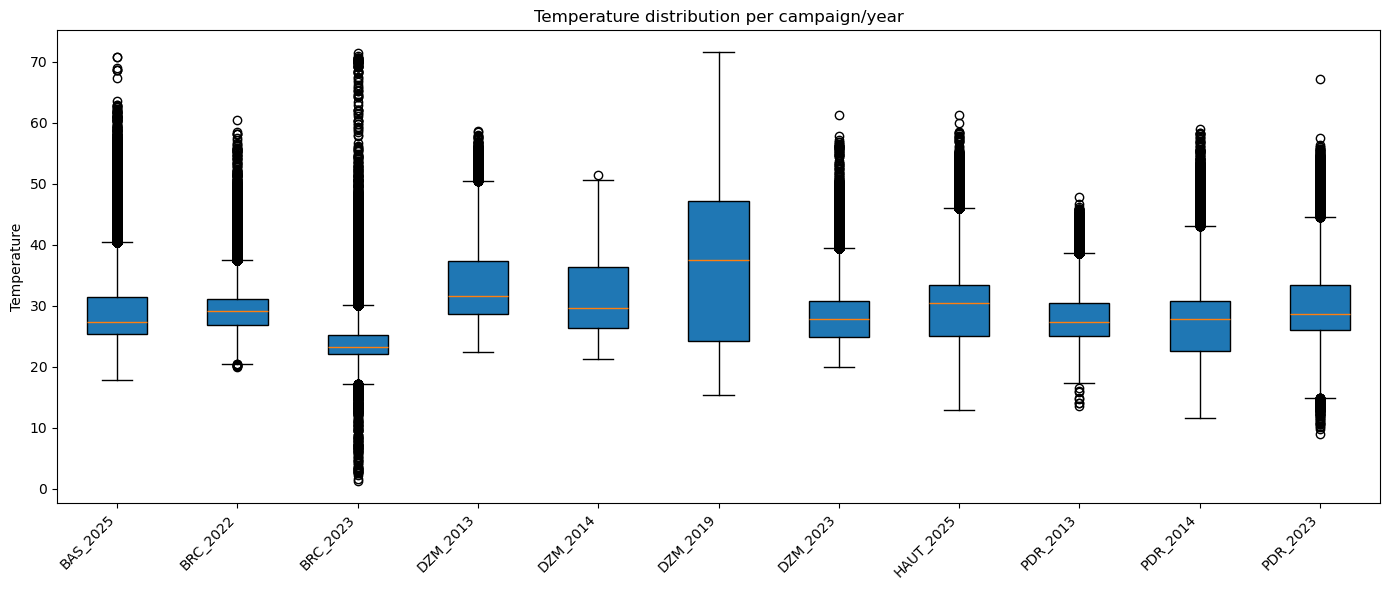

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/share/home/e2406751/Superresolution-TIR/data/HR_downsampled")

# Load all tifs
stats = {}
for tif in sorted(data_dir.glob("*.tif")):
    name = tif.stem  # e.g. "BAS_2025"
    with rasterio.open(tif) as src:
        data = src.read(1).astype(float)
        data[data < -1e30] = np.nan          # replace this line
        if src.nodata is not None:
            data[data == src.nodata] = np.nan  # keep this too as fallback
        vals = data[~np.isnan(data)].flatten()
        stats[name] = vals
        print(f"{name}: n={len(vals):,}  min={np.nanmin(vals):.2f}  max={np.nanmax(vals):.2f}  mean={np.nanmean(vals):.2f}")

# Boxplot
fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(stats.values(), labels=stats.keys(), vert=True, patch_artist=True)
ax.set_xticklabels(stats.keys(), rotation=45, ha='right')
ax.set_ylabel("Temperature")
ax.set_title("Temperature distribution per campaign/year")
plt.tight_layout()
plt.show()

Reproject all HR to same crs

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pathlib import Path

def reproject_to_epsg2154(src_path, dst_path):
    dst_crs = "EPSG:2154"
    with rasterio.open(src_path) as src:
        if src.crs.to_epsg() == 2154:
            print(f"{src_path.stem} already EPSG:2154, skipping")
            return
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update(crs=dst_crs, transform=transform, width=width, height=height)
        with rasterio.open(dst_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.bilinear
                )
        print(f"Reprojected {src_path.stem} → {dst_path}")

data_dir = Path("/share/home/e2406751/Superresolution-TIR/data/HR_downsampled")

for tif in sorted(data_dir.glob("*.tif")):
    reproject_to_epsg2154(tif, tif)  # overwrites in place

BAS_2025 already EPSG:2154, skipping
BRC_2022 already EPSG:2154, skipping
BRC_2023 already EPSG:2154, skipping
Reprojected DZM_2013 → /share/home/e2406751/Superresolution-TIR/data/processed/HR_downsampled/DZM_2013.tif
DZM_2014 already EPSG:2154, skipping
DZM_2019 already EPSG:2154, skipping
DZM_2023 already EPSG:2154, skipping
HAUT_2025 already EPSG:2154, skipping
Reprojected PDR_2013 → /share/home/e2406751/Superresolution-TIR/data/processed/HR_downsampled/PDR_2013.tif
PDR_2014 already EPSG:2154, skipping
PDR_2023 already EPSG:2154, skipping


In [ ]:
import rasterio
from pathlib import Path

data_dir = Path("/share/home/e2406751/Superresolution-TIR/data/HR_downsampled")

for tif in sorted(data_dir.glob("*.tif")):
    with rasterio.open(tif) as src:
        print(f"{tif.stem}: crs={src.crs.to_epsg()}, res={src.res}")

BAS_2025: crs=2154, res=(7.5, 7.5)
BRC_2022: crs=2154, res=(7.5, 7.5)
BRC_2023: crs=2154, res=(7.5, 7.5)
DZM_2013: crs=2154, res=(7.499999999999999, 7.499999999999999)
DZM_2014: crs=2154, res=(7.5, 7.5)
DZM_2019: crs=2154, res=(7.5, 7.5)
DZM_2023: crs=2154, res=(7.5, 7.5)
HAUT_2025: crs=2154, res=(7.5, 7.5)
PDR_2013: crs=2154, res=(7.5, 7.5)
PDR_2014: crs=2154, res=(7.5, 7.5)
PDR_2023: crs=2154, res=(7.5, 7.5)


## Splitting strategy

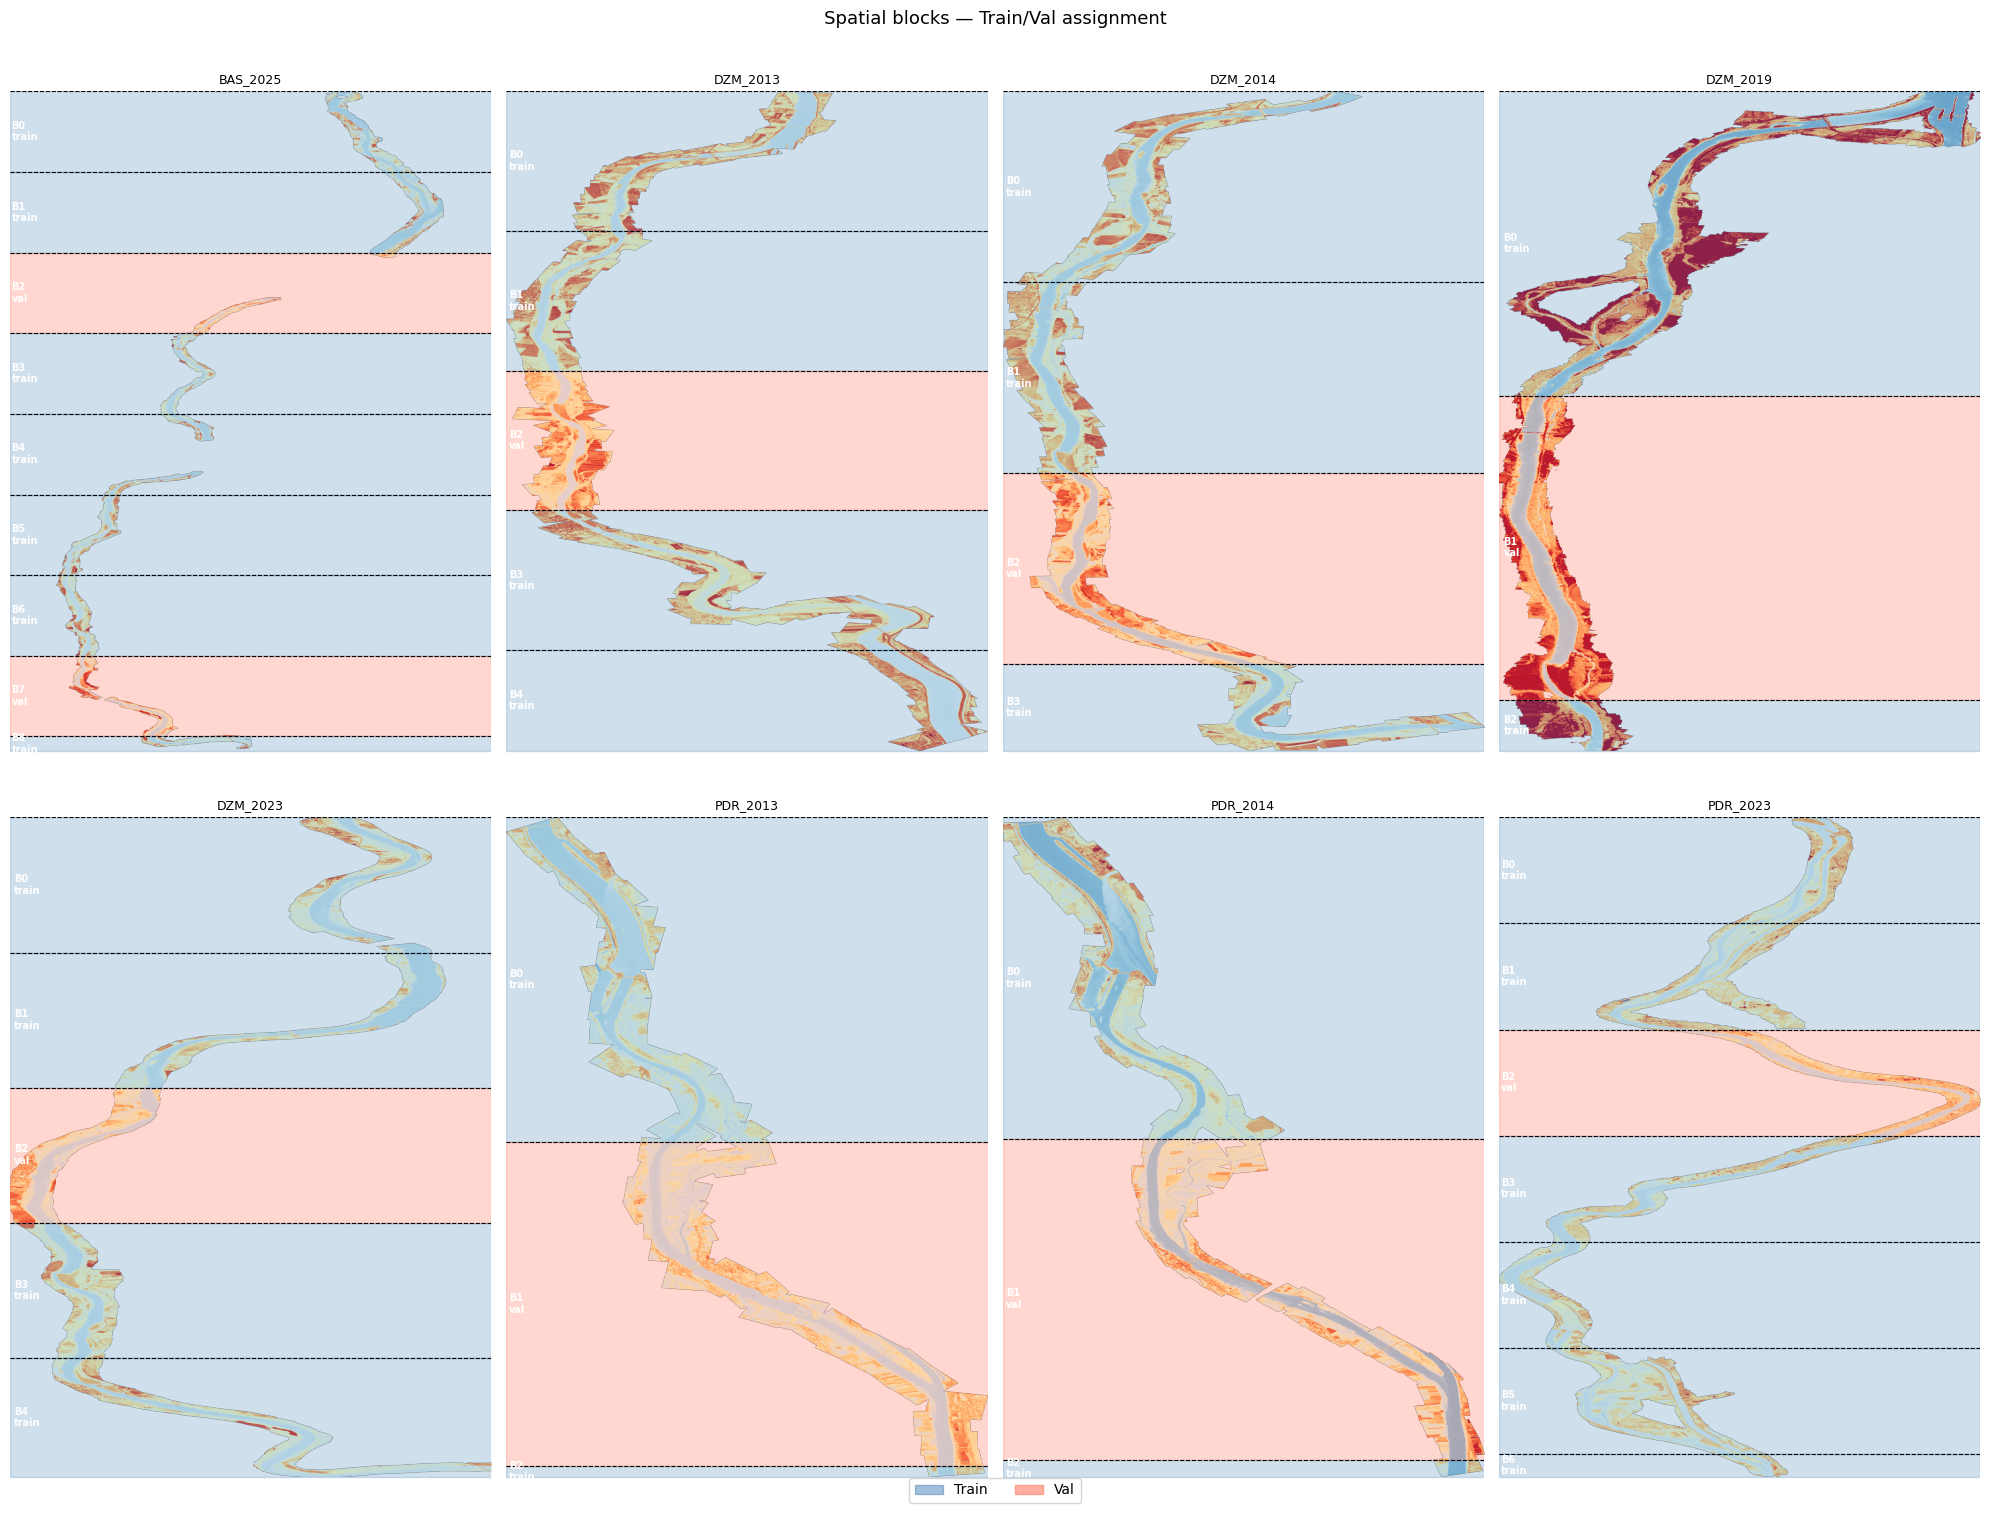

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import numpy as np
from pathlib import Path

data_dir = Path("/share/home/e2406751/Superresolution-TIR/data/HR_downsampled")
split_map_path = Path("/share/home/e2406751/Superresolution-TIR/data/split_map.json")

with open(split_map_path) as f:
    split_map = json.load(f)

colors = {"train": "steelblue", "val": "tomato"}

fig, axes = plt.subplots(2, 4, figsize=(20, 15))
axes = axes.flatten()

for ax, (fname, info) in zip(axes, split_map.items()):
    path = data_dir / fname
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data < -1e30] = np.nan

    # Show raster
    ax.imshow(data, cmap="RdYlBu_r", aspect="auto", vmin=10, vmax=50)

    # Overlay block boundaries and colors
    for block in info["blocks"]:
        row_start = block["row_start"]
        row_end = block["row_end"]
        color = colors[block["split"]]
        # Shaded rectangle over block
        ax.axhspan(row_start, row_end, alpha=0.25, color=color)
        # Boundary line
        ax.axhline(row_start, color="black", linewidth=0.8, linestyle="--")
        # Label in center of block
        mid = (row_start + row_end) / 2
        ax.text(5, mid, f"B{block['block_id']}\n{block['split']}",
                fontsize=7, color="white", fontweight="bold", va="center")

    ax.set_title(fname.replace(".tif", ""), fontsize=9)
    ax.axis("off")

# Legend
train_patch = mpatches.Patch(color="steelblue", alpha=0.5, label="Train")
val_patch = mpatches.Patch(color="tomato", alpha=0.5, label="Val")
fig.legend(handles=[train_patch, val_patch], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, 0.01))

plt.suptitle("Spatial blocks — Train/Val assignment", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

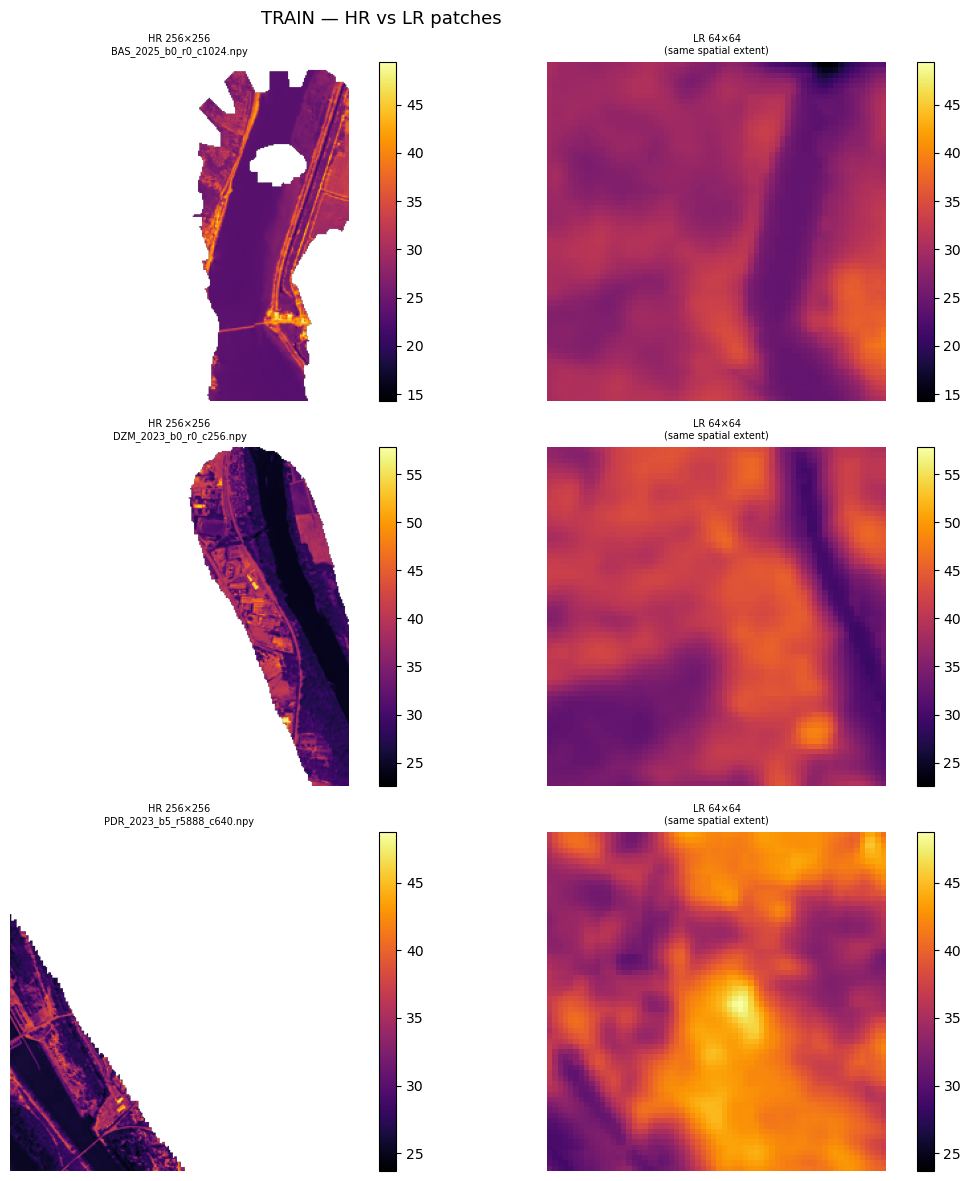

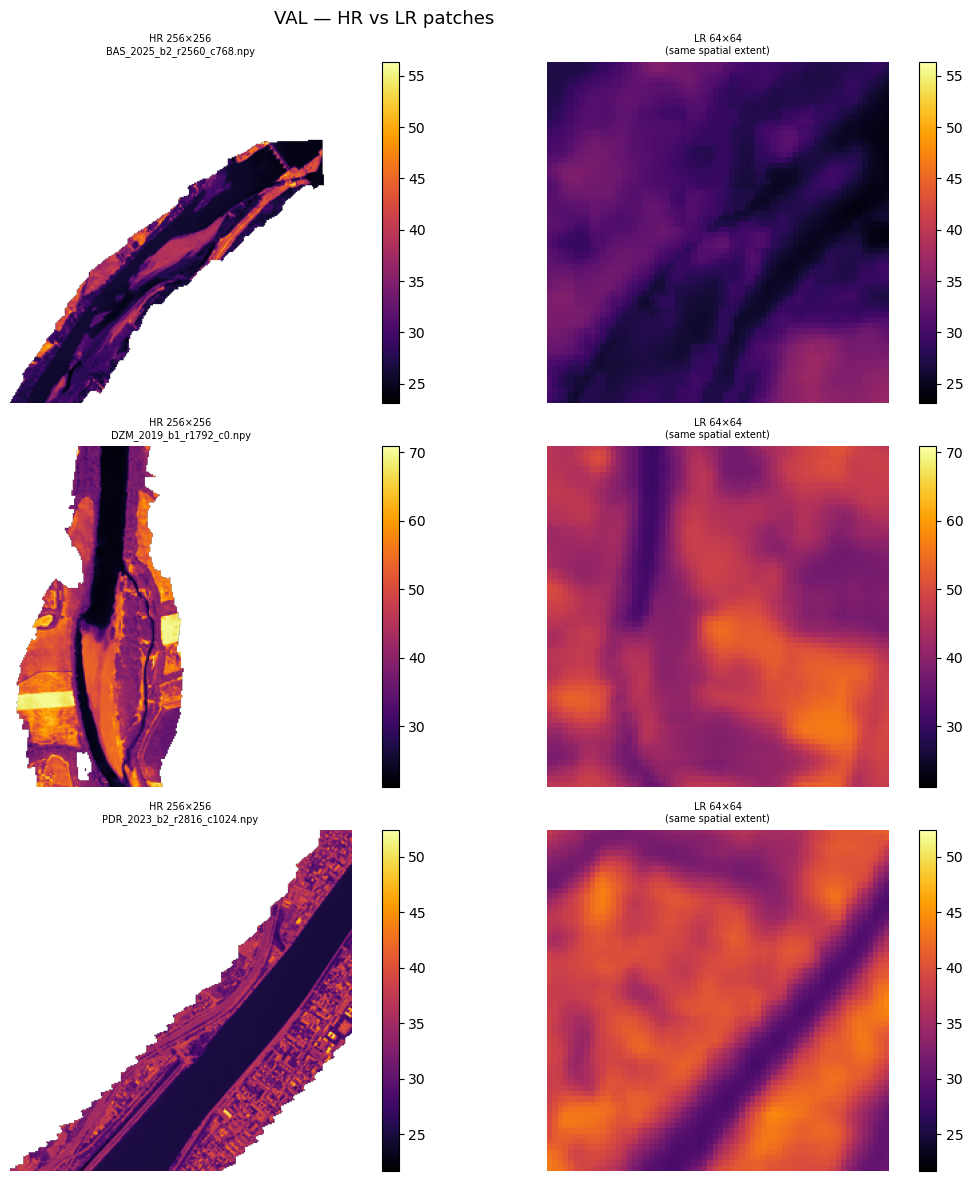

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

base = "/share/home/e2406751/Superresolution-TIR/data/processed/patches"

# Pick a few tiles from train and val
for split in ["train", "val"]:
    hr_dir = f"{base}/{split}/HR"
    lr_dir = f"{base}/{split}/LR"
    
    files = sorted(os.listdir(hr_dir))
    # Pick 3 evenly spaced samples
    samples = [files[i] for i in [0, len(files)//2, -1]]
    
    fig, axes = plt.subplots(len(samples), 2, figsize=(12, 4*len(samples)))
    fig.suptitle(f"{split.upper()} — HR vs LR patches", fontsize=13)
    
    for row, fname in enumerate(samples):
        hr = np.load(f"{hr_dir}/{fname}")
        lr = np.load(f"{lr_dir}/{fname}")
        
        # Shared color scale
        vmin = min(np.nanmin(hr), np.nanmin(lr))
        vmax = max(np.nanmax(hr), np.nanmax(lr))
        
        # HR
        im = axes[row, 0].imshow(hr, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"HR 256×256\n{fname}", fontsize=7)
        axes[row, 0].axis("off")
        plt.colorbar(im, ax=axes[row, 0], fraction=0.046)
        
        # LR
        im = axes[row, 1].imshow(lr, cmap="inferno", vmin=vmin, vmax=vmax)
        axes[row, 1].set_title(f"LR 64×64\n(same spatial extent)", fontsize=7)
        axes[row, 1].axis("off")
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046)
    
    plt.tight_layout()
    # plt.savefig(f"patch_inspection_{split}.png", dpi=150, bbox_inches="tight")
    plt.show()
    # print(f"Saved patch_inspection_{split}.png")

In [12]:
import json
with open('/share/home/e2406751/Superresolution-TIR/data/processed/patches/metadata.json') as f:
    meta = json.load(f)

from collections import Counter
train = Counter(v['campaign'] for v in meta.values() if v['split']=='train')
val   = Counter(v['campaign'] for v in meta.values() if v['split']=='val')
test  = Counter(v['campaign'] for v in meta.values() if v['split']=='test')

print('TRAIN:'); [print(f'  {k}: {v}') for k,v in sorted(train.items())]
print('VAL:');   [print(f'  {k}: {v}') for k,v in sorted(val.items())]
print('TEST:');  [print(f'  {k}: {v}') for k,v in sorted(test.items())]

TRAIN:
  BAS_2025: 81
  DZM_2013: 59
  DZM_2014: 30
  DZM_2019: 14
  DZM_2023: 47
  PDR_2013: 16
  PDR_2014: 16
  PDR_2023: 105
VAL:
  BAS_2025: 6
  DZM_2013: 4
  DZM_2014: 5
  DZM_2019: 4
  DZM_2023: 4
  PDR_2013: 3
  PDR_2014: 4
  PDR_2023: 6
TEST:
  BRC_2022: 10
  BRC_2023: 11
  HAUT_2025: 43


[None, None, None]

## MISC